In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas_datareader.data as web

In [36]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [48]:
def rolling_factor_model(input_data, formula, window_size):
    coeffs = []

    for start_index in range(len(input_data) - window_size + 1):        
        end_index = start_index + window_size

        # define and fit the regression model 
        ff_model = smf.ols(
            formula=formula, 
            data=input_data.iloc[start_index:end_index]
        ).fit()
   
        # store coefficients
        coeffs.append(ff_model.params)
    
    coeffs_df = pd.DataFrame(
        coeffs, 
        index=input_data.index[window_size - 1:]
    )

    return coeffs_df

In [17]:
def getAssetsStock(tickers, startDate, endDate):
    
    dic = {}
    file_path = "../Data-collection/dailyStock"
    
    for ticker in tickers:
        ticker_df = pd.read_csv(f"{file_path}/{ticker}.csv", encoding="utf-8")
        ticker_df['Date'] = pd.to_datetime(ticker_df['Date'])
        ticker_df = ticker_df.set_index('Date')
        ticker_df = ticker_df.loc[START_DATE:END_DATE]
        
        dic[ticker] = ticker_df['adj_close'].resample('ME').last().pct_change()
    
    returns_df = pd.DataFrame(dic)
    returns_df.index = returns_df.index.to_period('M')
    
    return returns_df.dropna()

### 파마 프렌치 데이터 가져오기

In [26]:
df_three_factor = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='2010-01-01', end='2018-12-31')[0]
#백분율을 소수로 변경
df_three_factor = df_three_factor.div(100)
df_three_factor

,Mkt-RF,SMB,HML,RF
Date,,,,
2010-01,-0.0335,0.0043,0.0033,0.0000
2010-02,0.0339,0.0118,0.0318,0.0000
2010-03,0.0630,0.0146,0.0219,0.0001
2010-04,0.0199,0.0484,0.0296,0.0001
2010-05,-0.0790,0.0013,-0.0248,0.0001
...,...,...,...,...
2018-08,0.0345,0.0117,-0.0393,0.0016
2018-09,0.0006,-0.0229,-0.0168,0.0015
2018-10,-0.0765,-0.0467,0.0343,0.0019


### 주가정보 가져오기

In [27]:
ASSETS = ['AMZN', 'GOOG', 'AAPL', 'MSFT']
WEIGHTS = [0.25, 0.25, 0.25, 0.25]
START_DATE = '2009-12-01' #단순수익률 산정이 필요하니 조회가 필요한 일자에서 -1Month로 조회
END_DATE = '2018-12-31'

### 포트폴리오 수익률 도식화

In [29]:
#포트폴리오 통합 수익률
asset_df = getAssetsStock(ASSETS, START_DATE, END_DATE)
asset_df['portfolio_returns'] = np.matmul(asset_df[ASSETS].values, WEIGHTS)

<Axes: title={'center': '포트폴리오 수익률'}, xlabel='Date'>

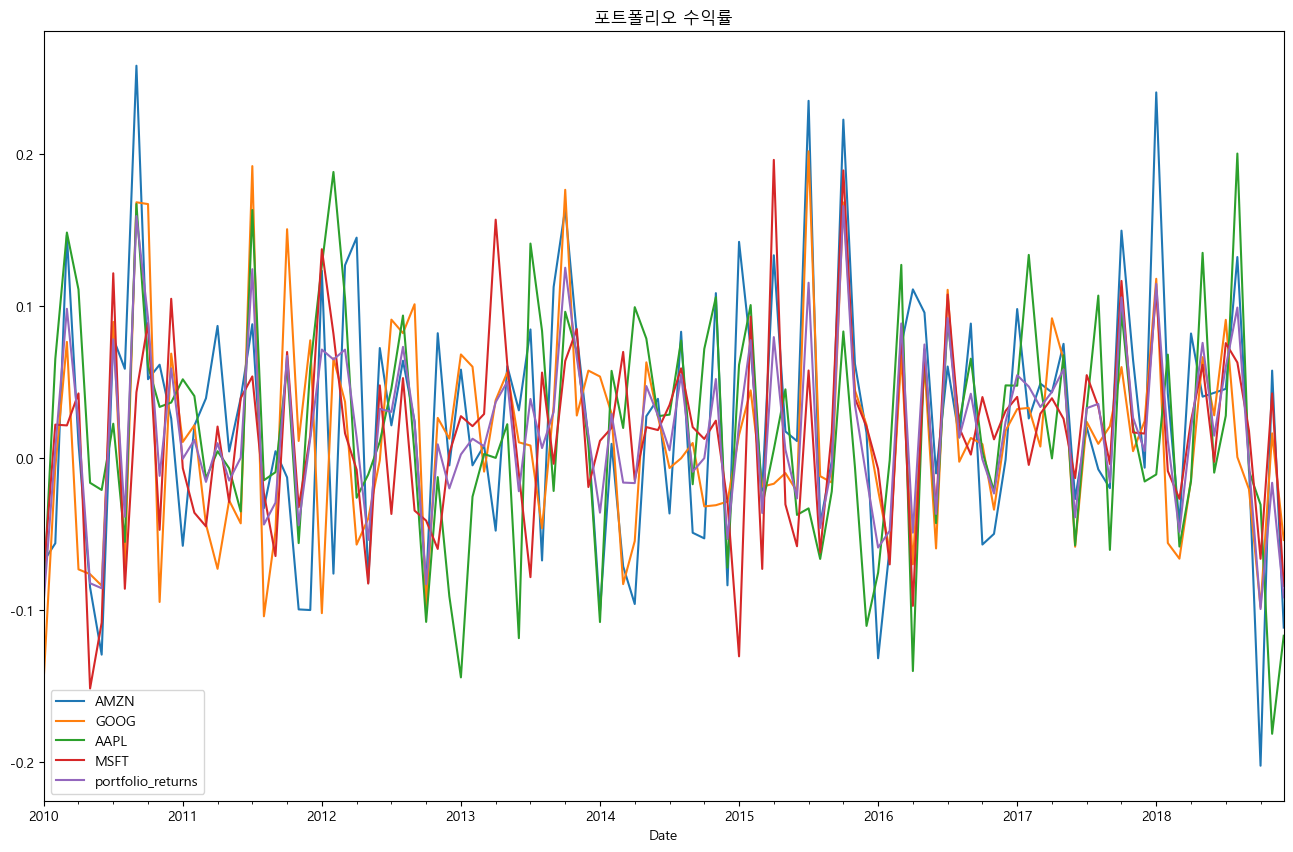

In [39]:
asset_df.plot(title="포트폴리오 수익률", figsize=(16, 10))

### 팩터 데이터와 주가 정보 병합

In [46]:
ff_data = asset_df.join(df_three_factor).drop(ASSETS, axis=1)
ff_data.columns = ['portf_rtn', 'mkt', 'smb', 'hml', 'rf']
ff_data['portf_ex_rtn'] = ff_data.portf_rtn - ff_data.rf

<Axes: title={'center': '롤링 팩터 모델'}, xlabel='Date'>

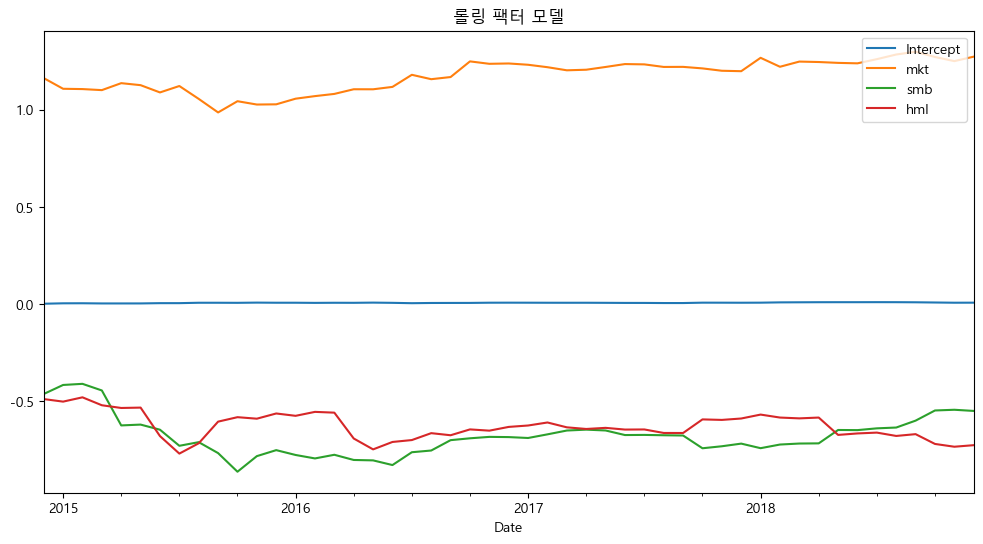

In [49]:
results_df = rolling_factor_model(ff_data, 
                                  'portf_ex_rtn ~ mkt + smb + hml', 
                                  window_size=60)

results_df.plot(title = '롤링 팩터 모델',figsize=(12, 6))